# Pennsylvania Hospital Accessibility — Multi-Download Workflow


**Real-world question:** *Which Pennsylvania counties are well-served (versus poorly-served) by hospitals within a 10-mile drive band?*


## Install GAS Client SDK

In [5]:
%pip install -q gas-client

Note: you may need to restart the kernel to use updated packages.


## Imports

In [6]:
from urllib.parse import urljoin
from IPython.display import HTML, Image, display
from gas_client import GasClient

## User Settings


In [7]:
import os
from pathlib import Path

from dotenv import load_dotenv

project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

load_dotenv(project_root / ".env")

server_url = "http://127.0.0.1:4042"

openai_api_key = os.getenv("OPENAI_API_KEY")
if not openai_api_key:
    raise RuntimeError("Set OPENAI_API_KEY in the repo .env file before running this notebook.")

census_api_key = os.getenv("US_CENSUS_API_KEY")

client = GasClient(
    server_url,
    default_credentials={"OPENAI_API_KEY": openai_api_key},
    artifact_delivery="URL",
)

credentials = {"OPENAI_API_KEY": openai_api_key}
timeout_seconds = 2400


## Bind to the Three Agents

In [8]:
data_agent = client.agent("geospatial_data_retrieval_agent")
vector_agent = client.agent("vector_analysis_agent")
mapping_agent = client.agent("mapping_agent")

for agent in [data_agent, vector_agent, mapping_agent]:
    print(agent.agent_id, agent.status().get("status"))

geospatial_data_retrieval_agent available
vector_analysis_agent available
mapping_agent available


## Step 1: One Data Retrieval Call → Three Datasets


In [9]:
multi_retrieval_result = data_agent.run_streaming_task((
        "Please download three Pennsylvania datasets:\n"
        "1) Pennsylvania county boundaries from the U.S. Census Bureau TIGER source. "
        "Return a clean GeoPackage with county geometry, GEOID, county name, and STATEFP fields. "
        "Restrict the output strictly to Pennsylvania (STATEFP = 42).\n"
        "2) Pennsylvania hospitals from OpenStreetMap (amenity=hospital and healthcare=hospital). "
        "Return a clean point GeoPackage covering the state of Pennsylvania, with at least name and "
        "the original OSM tags retained where available.\n"
        "3) Pennsylvania major highways from OpenStreetMap (highway=motorway and highway=trunk). "
        "Return a clean line GeoPackage covering the state of Pennsylvania with name and highway-type fields.\n\n"
        "All three datasets should use WGS84 (EPSG:4326)."
    ),
)

[20:34:21] stream_connected: Streaming connection established.
[20:34:21] Geospatial Data Retrieval Agent: I received your request.
[20:34:21] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[20:34:21] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[20:34:21] task_accepted: Task accepted. Starting streaming execution.
[20:34:22] Geospatial Data Retrieval Agent: Next I will start the workflow with the prepared inputs.
[20:34:22] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[20:34:24] Geospatial Data Retrieval Agent: The request was decomposed into 3 sub-request(s).
[20:34:24] Geospatial Data Retrieval Agent: I detected 3 datasets in your request. I will download each one as a separate sub-task and return all artifacts.
[20:34:24] Geospatial Data Retrieval Agent:

In [10]:
counties_url = client.get_artifact_urls(multi_retrieval_result)[0]
hospitals_url = client.get_artifact_urls(multi_retrieval_result)[1]
highways_url = client.get_artifact_urls(multi_retrieval_result)[2]

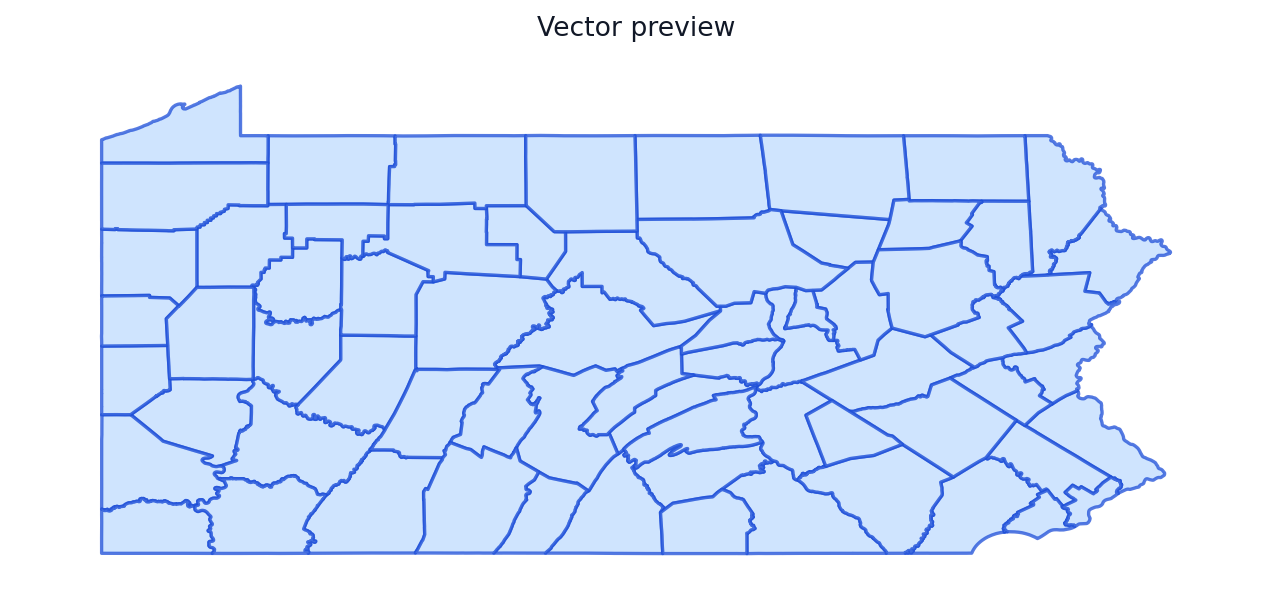

GEOID,NAME,STATEFP
42111,Somerset,42
42133,York,42
42027,Centre,42
42041,Cumberland,42
42035,Clinton,42


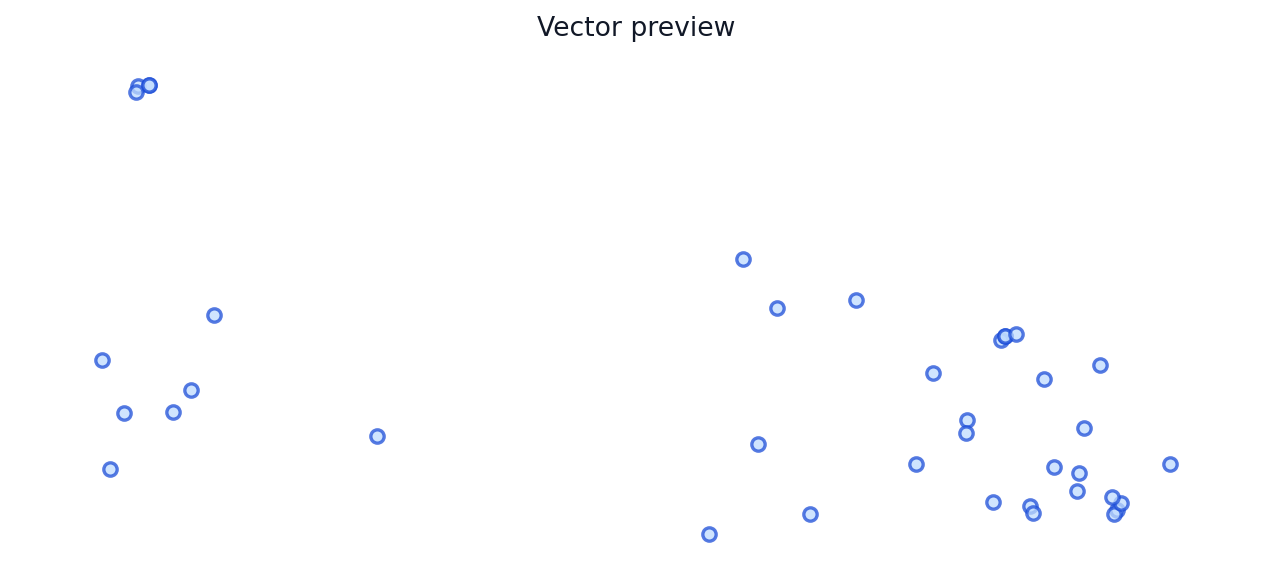

addr:city,addr:housenumber,addr:postcode,addr:street,amenity,emergency,gnis:feature_id,healthcare,healthcare:speciality,name,opening_hours,operator,operator:short,operator:wikidata,operator:wikipedia,phone,website,id,type,ele,check_date,wikidata,wikipedia,short_name,addr:state,toilets:wheelchair,wheelchair,wheelchair:description,beds,operator:type,addr:unit,description,email,fax,healthcare:for,brand
Pittsburgh,3811,15213,O'Hara Street,hospital,no,1196551,hospital,psychiatry,Western Psychiatric Hospital,24/7,University of Pittsburgh Medical Center,UPMC,Q7896131,en:University of Pittsburgh Medical Center,+1 412 624 2100,https://www.upmc.com/locations/hospitals/western-psychiatric/,357330745,node,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
nan,nan,nan,nan,hospital,nan,1212446,hospital,nan,Chicora Medical Center,nan,nan,nan,nan,nan,nan,nan,357363756,node,418,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Philadelphia,840,19107,Walnut Street,hospital,yes,2350401,hospital,ophthalmology,Wills Eye Hospital,24/7,nan,nan,nan,nan,+1 215 928 3000,https://www.willseye.org/,357374314,node,nan,2025-10-07,Q8022473,en:Wills Eye Hospital,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Temple,704,19560,Hay Road,hospital,no,2488908,hospital,psychiatry,KidsPeace Berks Campus,nan,nan,nan,nan,nan,+1 610 929 4670,https://www.kidspeace.org/pa-community-programs/,357382533,node,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Norristown,50,19401,Beech Drive,hospital,no,nan,hospital,psychiatry,Montgomery County Emergency Service - Crisis Services,24/7,nan,nan,nan,nan,+1-610-279-6100,http://www.mces.org/,1096960819,node,nan,nan,nan,nan,MCES,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


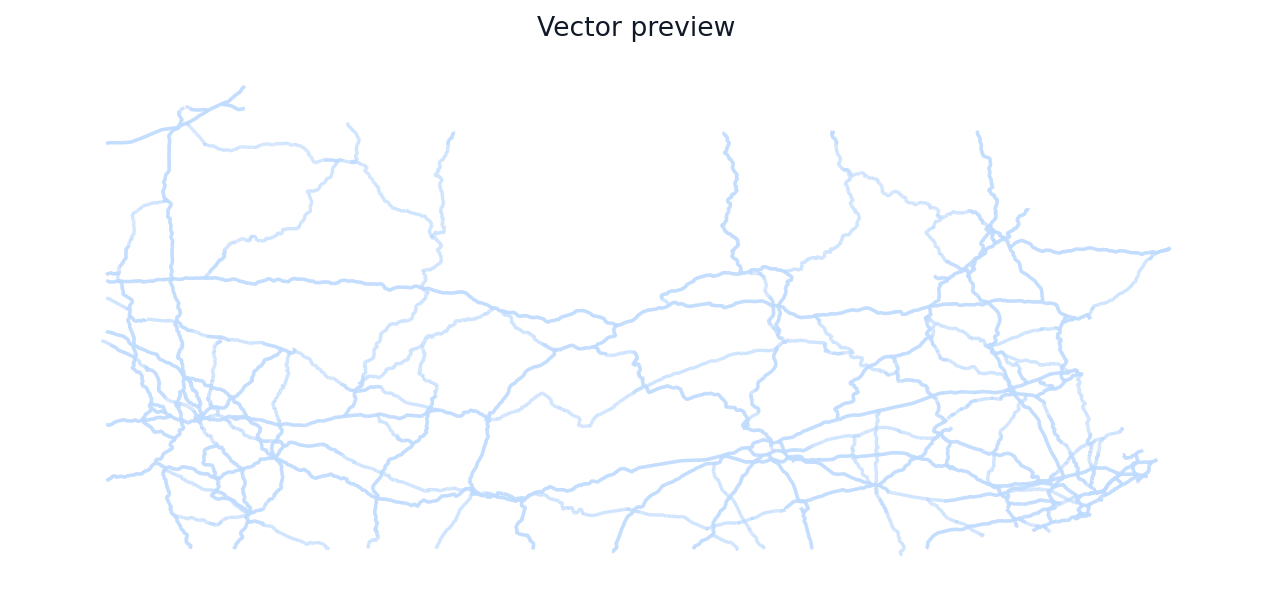

name,highway
,motorway
,motorway
,motorway
,trunk
Appalachian Thruway,motorway


In [11]:
client.display_artifacts(multi_retrieval_result)

## Step 2: Compute 10-Mile Hospital Coverage Per County


In [12]:
coverage_result = vector_agent.run_streaming_task((
        "Compute hospital accessibility per Pennsylvania county using the provided layers. "
        "Inputs (in this order): (1) PA county polygons, (2) PA hospital points, (3) PA highways (not used in the analysis, ignore). "
        "Steps: "
        "a) Reproject counties and hospitals to EPSG:5070 (NAD83 Conus Albers, units = meters) for buffering and area math. "
        "b) Buffer each hospital point by 16093 meters (10 miles) and dissolve all buffers into one coverage polygon. "
        "c) Intersect the dissolved coverage with each county; compute covered_area_m2 per county (0 if no overlap). "
        "d) Compute county_area_m2 from the projected county geometry and a new numeric field "
        "   coverage_pct = covered_area_m2 / county_area_m2 * 100, clamped to [0, 100]. "
        "e) Reproject the result back to EPSG:4326. "
        "Return one GeoPackage of PA counties with original identifiers (GEOID, NAME) and the new "
        "coverage_pct field. Do not return the hospital or highway layers from this step."
    ),
    input_datasets=[counties_url, hospitals_url, highways_url],
)

[20:38:51] stream_connected: Streaming connection established.
[20:38:52] Vector Analysis Agent: I received your request.
[20:38:52] Vector Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 3 dataset reference(s).
[20:38:52] Vector Analysis Agent: I found the required credentials and can start the model-backed workflow.
[20:38:52] task_accepted: Task accepted. Starting streaming execution.
[20:38:52] Vector Analysis Agent: Next I will start the workflow with the prepared inputs.
[20:38:53] Vector Analysis Agent: I will load the requested vector/tabular inputs, run code-driven analysis, and save a final dataset artifact from 3 dataset reference(s).
[20:38:53] Vector Analysis Agent: I detected a common vector operation and will first try a deterministic GeoPandas workflow.
[20:38:53] Vector Analysis Agent: Computed buffered point coverage for 67 polygon feature(s) using 39 point feature(s), a 16,093-meter buffer, and 

In [13]:
coverage_url = client.get_artifact_urls(coverage_result)[0]
coverage_url

'http://127.0.0.1:4042/agents/vector_analysis_agent/data/vector_analysis_agent-0088-dtje-3324.gpkg'

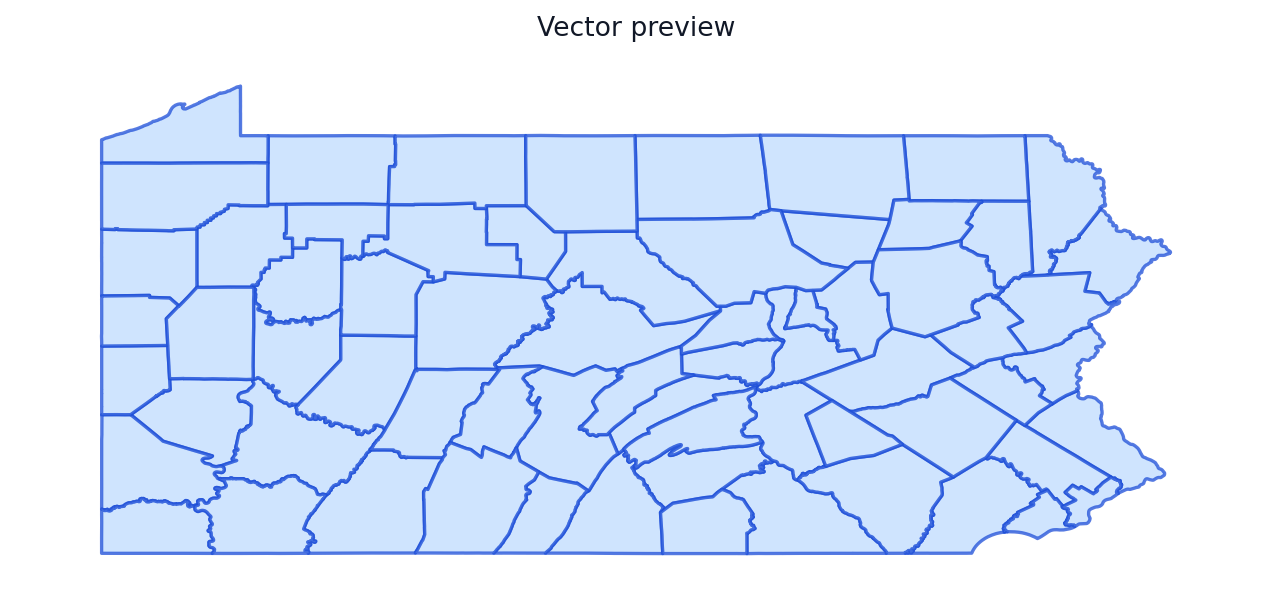

GEOID,NAME,STATEFP,county_area_m2,covered_area_m2,coverage_pct
42111,Somerset,42,2801507333.666942,207987923.3345578,7.424143454313888
42133,York,42,2358556963.377491,868737139.688406,36.83341777102388
42027,Centre,42,2879146357.7127104,0.0,0.0
42041,Cumberland,42,1425438799.532089,342629094.92376745,24.036745389296126
42035,Clinton,42,2327625350.2760706,0.0,0.0


In [14]:
client.display_artifacts(coverage_result)

## Step 3: Map the Result

The mapping agent renders the choropleth of `coverage_pct` with hospitals and major highways overlaid for context.

In [15]:
map_result = mapping_agent.run_streaming_task((
        "Create a professional county-level choropleth map of Pennsylvania showing 10-mile hospital coverage. "
        "Inputs (in this order): (1) PA counties with a coverage_pct field, (2) PA hospital points, "
        "(3) PA major highways. "
        "Use coverage_pct for county fill color, a 5-class sequential green color ramp (light = low coverage, "
        "dark = high coverage), thin dark-gray county outlines, hospital points as small red dots on top, "
        "and highways as semi-transparent dark gray lines beneath the hospital points. "
        "Use the EPSG:5070 (Conus Albers) projection, a legend outside the map area listing the choropleth "
        "breaks and a small inset legend for hospitals and highways, the title "
        "'Pennsylvania Counties: % Area Within 10 Miles of a Hospital', and a small data-source caption "
        "crediting OpenStreetMap and U.S. Census TIGER."
    ),
    input_datasets=[coverage_url, hospitals_url, highways_url],
)



[20:38:53] stream_connected: Streaming connection established.
[20:38:54] Mapping Agent: I received your request.
[20:38:54] Mapping Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 3 dataset reference(s).
[20:38:54] Mapping Agent: I found the required credentials and can start the model-backed workflow.
[20:38:54] task_accepted: Task accepted. Starting streaming execution.
[20:38:54] Mapping Agent: Next I will start the workflow with the prepared inputs.
[20:38:54] Mapping Agent: I will inspect the requested visualization and the 3 dataset reference(s), then choose whether a map or chart is the best way to answer it.
[20:38:55] Mapping Agent: I am drafting visualization code now. This is attempt 1; I will run the code and check whether it creates the requested output correctly.
[20:39:05] Mapping Agent: Still working on map_design: I am drafting visualization code now. This is attempt 1; I will run the code and check wheth

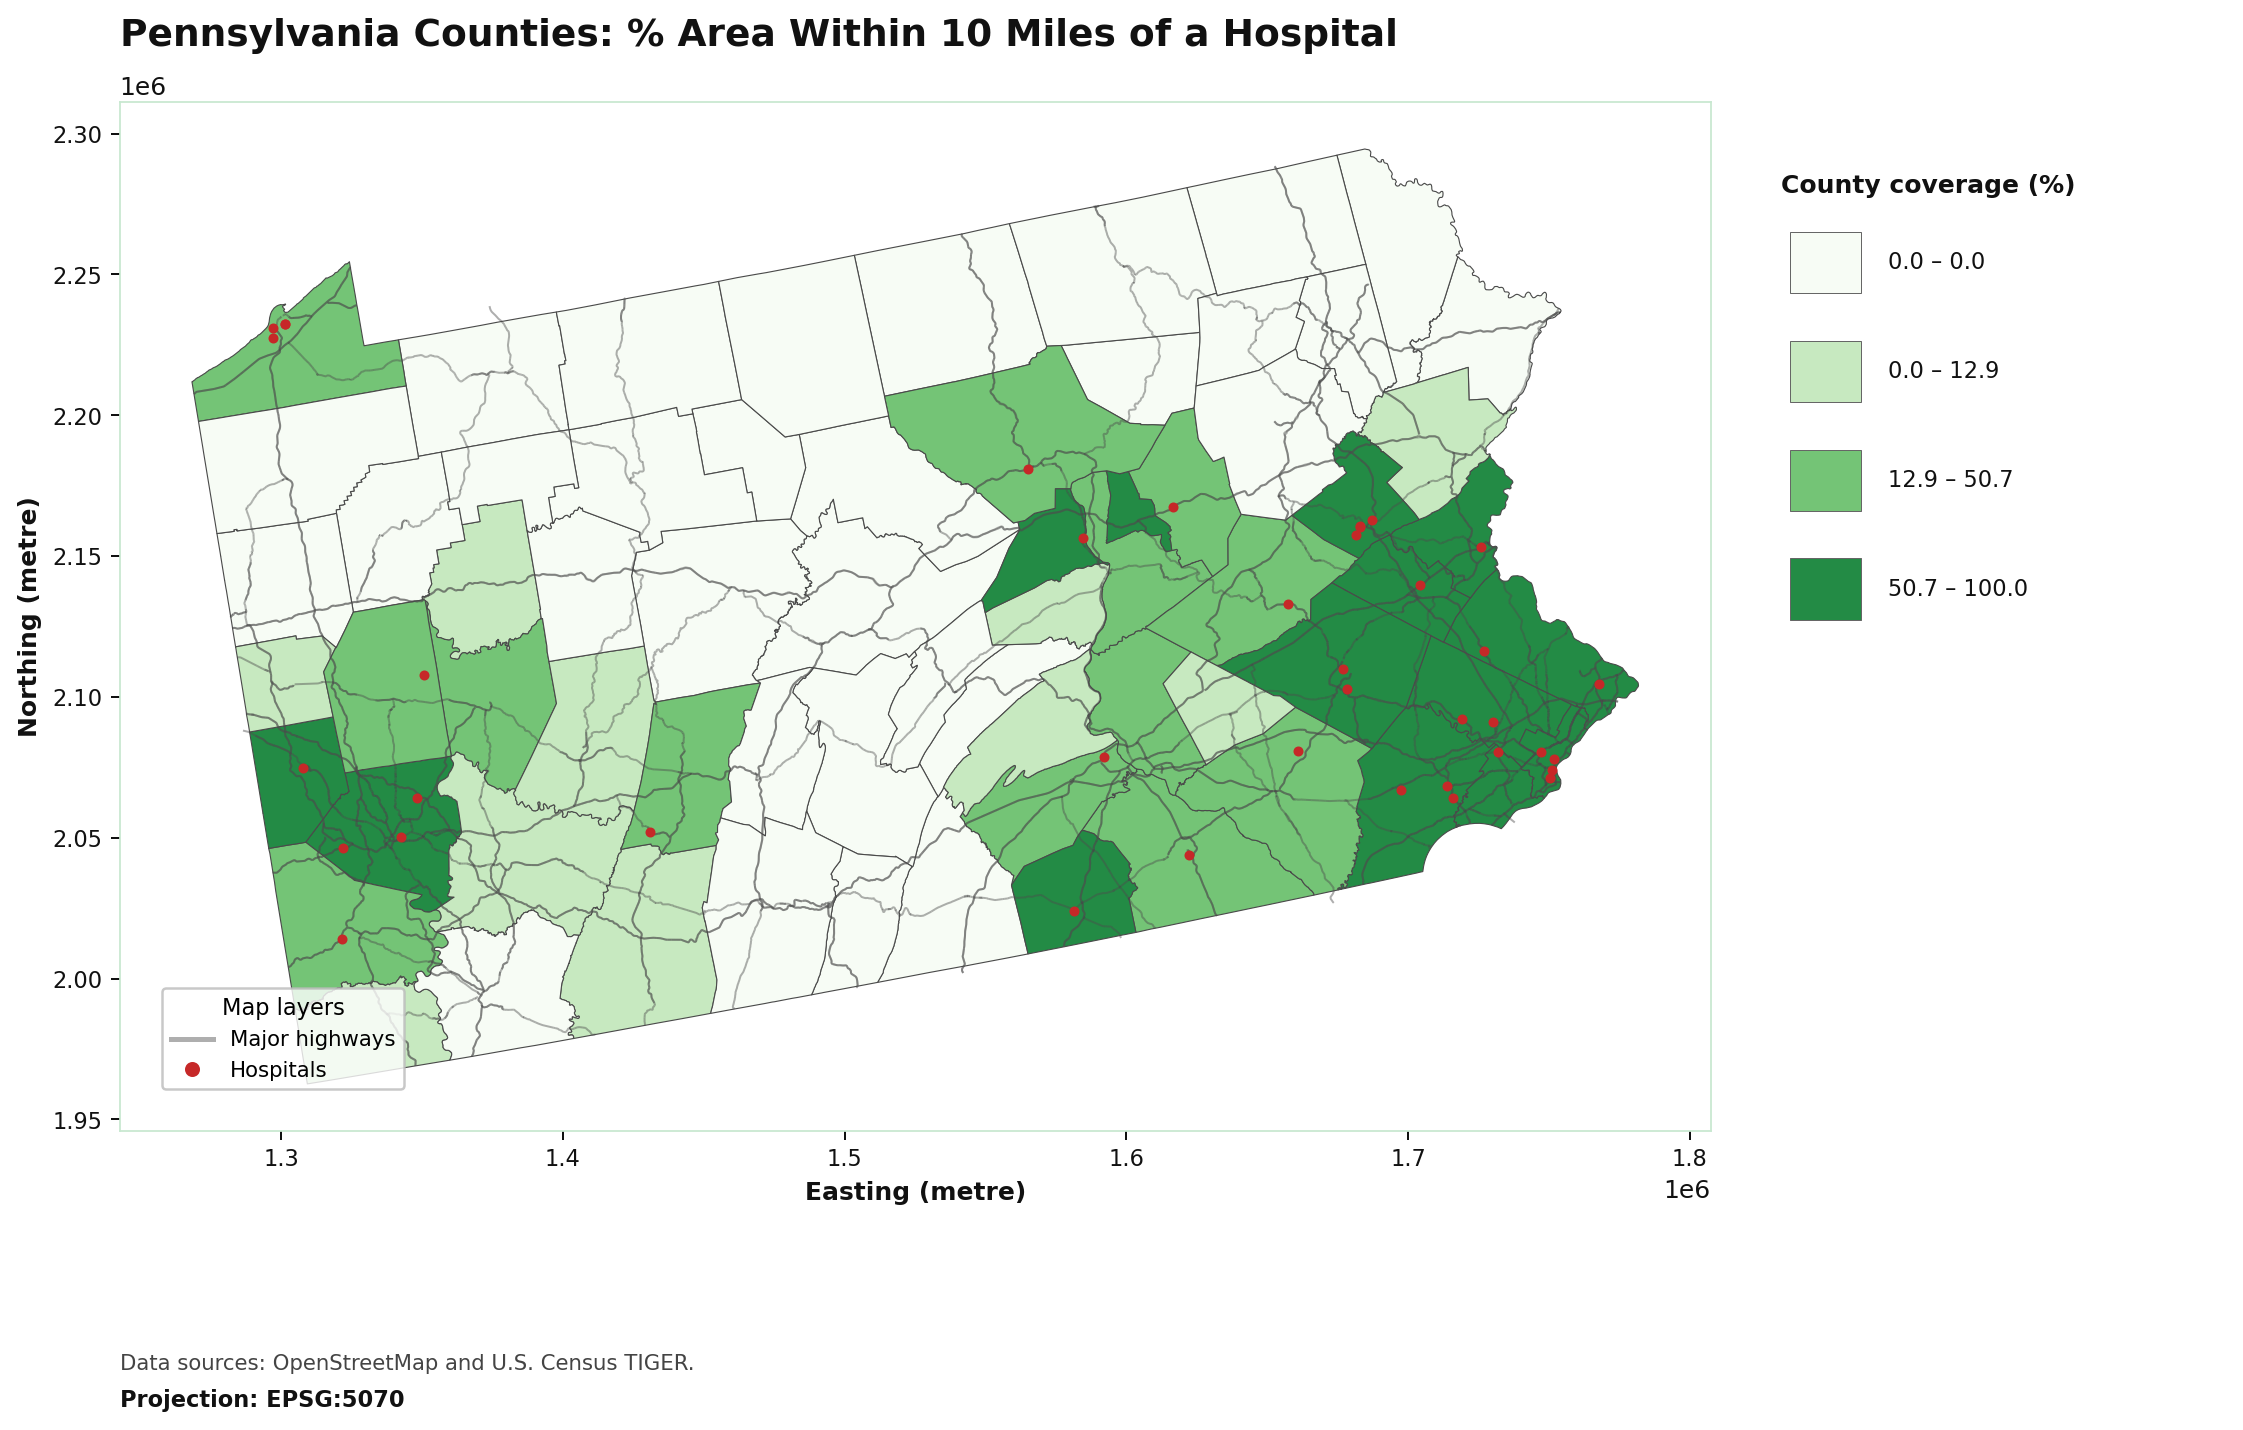

In [16]:
client.display_artifacts(map_result)